In [1]:
%%time
%matplotlib inline

import importlib
import new_import  

importlib.reload(new_import)


from new_import import *

CPU times: user 13.2 s, sys: 3.27 s, total: 16.5 s
Wall time: 10.4 s


In [2]:
%%time
# Cấu hình Daskgateway
cluster, client = notebook_utils.initialize_dask(use_gateway=True, workers=(1,10))
# Khai báo 1 Datacube là dc
dc = datacube.Datacube()

client

Starting new cluster.
CPU times: user 706 ms, sys: 38 ms, total: 744 ms
Wall time: 2min 56s


Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: https://hub.asia.easi-eo.solutions/services/dask-gateway/clusters/easihub.8f4044c87f8b4423883c64edb421d283/status,


In [3]:
date_range = ('2022-09-01', '2023-10-30')
longtitude_range = (105.5, 106.4)
latitude_range = (9.2, 10.0) 

coordinates = (longtitude_range, latitude_range)

In [8]:
# tải dữ liệu vh vv từ vệ tinh sentinel-1
dsvh, dsvv = load_data_sen1(dc, date_range, coordinates)

<xarray.Dataset> Size: 25GB
Dimensions:      (time: 35, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 280B 2022-09-06T22:46:14.500000 ... 20...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    vv           (time, y, x) float32 12GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    vh           (time, y, x) float32 12GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [9]:
average_vh = calculate_max(dsvh, time_pattern='1M')
progress(average_vh)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

2025-01-01 14:17:23,166 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7fea76fa76e0>>, <Task finished name='Task-50' coro=<MultiProgressBar.listen() done, defined at /env/lib/python3.12/site-packages/distributed/diagnostics/progressbar.py:281> exception=OSError('Timed out trying to connect to gateway://traefik-dask-gateway.easihub:80/easihub.8f4044c87f8b4423883c64edb421d283 after 30 s')>)
Traceback (most recent call last):
  File "/env/lib/python3.12/site-packages/distributed/utils.py", line 1952, in wait_for
    return await fut
           ^^^^^^^^^
  File "/env/lib/python3.12/site-packages/dask_gateway/comm.py", line 48, in connect
    stream = await plain_stream.start_tls(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
asyncio.exceptions.CancelledError

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File

In [10]:
average_vv = calculate_max(dsvv, time_pattern='1M')
progress(average_vv)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

2025-01-01 14:17:23,169 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7fea76fa76e0>>, <Task finished name='Task-53' coro=<MultiProgressBar.listen() done, defined at /env/lib/python3.12/site-packages/distributed/diagnostics/progressbar.py:281> exception=OSError('Timed out trying to connect to gateway://traefik-dask-gateway.easihub:80/easihub.8f4044c87f8b4423883c64edb421d283 after 30 s')>)
Traceback (most recent call last):
  File "/env/lib/python3.12/site-packages/distributed/utils.py", line 1952, in wait_for
    return await fut
           ^^^^^^^^^
  File "/env/lib/python3.12/site-packages/dask_gateway/comm.py", line 48, in connect
    stream = await plain_stream.start_tls(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
asyncio.exceptions.CancelledError

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File

In [11]:
%%time
average_vh.compute()
average_vv.compute()

CPU times: user 8.91 s, sys: 8.19 s, total: 17.1 s
Wall time: 4min 22s


<xarray.DataArray 'vv' (time: 14, y: 8874, x: 9902)> Size: 5GB
array([[[0.11669904, 0.11758084, 0.11906392, ..., 0.28758633,
         0.28219926, 0.2772522 ],
        [0.11669904, 0.11758084, 0.11906392, ..., 0.2977812 ,
         0.29101884, 0.29437637],
        [0.123698  , 0.12604341, 0.1280164 , ..., 0.32462057,
         0.3412418 , 0.33167392],
        ...,
        [0.0860377 , 0.08814673, 0.08877262, ..., 0.07386821,
         0.07060286, 0.06853181],
        [0.08429613, 0.08629276, 0.08680432, ..., 0.07478057,
         0.07110291, 0.0690233 ],
        [0.08452614, 0.08514079, 0.08482596, ..., 0.07478057,
         0.07110291, 0.0690233 ]],

       [[0.01042379, 0.00980564, 0.00910663, ..., 0.2470314 ,
         0.2617413 , 0.26719323],
        [0.01042379, 0.00980564, 0.00910663, ..., 0.27529654,
         0.29579878, 0.32552853],
        [0.01044675, 0.00982475, 0.00910367, ..., 0.31401765,
         0.33365095, 0.39374885],
...
        [0.17662166, 0.22541875, 0.20114286, ..., 0.07318421,
         0.06952109, 0.06355632],
        [0.15515417, 0.18215807, 0.16962345, ..., 0.07190494,
         0.06896029, 0.06449131],
        [0.13391307, 0.13972393, 0.13716471, ..., 0.07190494,
         0.06896029, 0.06449131]],

       [[0.0131518 , 0.01348239, 0.01371657, ..., 0.26908004,
         0.27120155, 0.31028602],
        [0.0131518 , 0.01348239, 0.01371657, ..., 0.30983835,
         0.32544178, 0.3898932 ],
        [0.01299412, 0.01317724, 0.01338189, ..., 0.35239032,
         0.3864454 , 0.42996913],
        ...,
        [0.08935151, 0.08881748, 0.0870014 , ..., 0.02987257,
         0.02962873, 0.03015281],
        [0.09377098, 0.0899022 , 0.08724123, ..., 0.02970332,
         0.02930899, 0.02925275],
        [0.10420843, 0.09353115, 0.0881807 , ..., 0.02970332,
         0.02930899, 0.02925275]]], dtype=float32)
Coordinates:
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
  * time         (time) datetime64[ns] 112B 2022-09-30 2022-10-31 ... 2023-10-31
Attributes:
    units:         intensity
    nodata:        nan
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [12]:
data_sen2 = load_data_sen2(dc, date_range, coordinates)
notebook_utils.heading(notebook_utils.xarray_object_size(data_sen2))
display(data_sen2)

No datasets require offset correction
The valid_data_mask and scale (no offset) have been applied to the reflectance bands


<xarray.Dataset> Size: 129GB
Dimensions:      (time: 163, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2022-09-02T03:35:23.960000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    red          (time, y, x) float32 57GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) float32 57GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    scl          (time, y, x) uint8 14GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [13]:
%%time
# Tiến hành loại bỏ các vị trí bị mây ảnh hưởng
result = mask_cloud(data_sen2)
progress(result)

{'0': 'no data',
 '1': 'saturated or defective',
 '2': 'dark area pixels',
 '3': 'cloud shadows',
 '4': 'vegetation',
 '5': 'bare soils',
 '6': 'water',
 '7': 'unclassified',
 '8': 'cloud medium probability',
 '9': 'cloud high probability',
 '10': 'thin cirrus',
 '11': 'snow or ice'}

CPU times: user 966 ms, sys: 20.3 ms, total: 986 ms
Wall time: 983 ms


VBox()

2025-01-01 14:18:38,423 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7fea76fa76e0>>, <Task finished name='Task-1001' coro=<MultiProgressBar.listen() done, defined at /env/lib/python3.12/site-packages/distributed/diagnostics/progressbar.py:281> exception=OSError('Timed out trying to connect to gateway://traefik-dask-gateway.easihub:80/easihub.8f4044c87f8b4423883c64edb421d283 after 30 s')>)
Traceback (most recent call last):
  File "/env/lib/python3.12/site-packages/distributed/utils.py", line 1952, in wait_for
    return await fut
           ^^^^^^^^^
  File "/env/lib/python3.12/site-packages/dask_gateway/comm.py", line 45, in connect
    plain_stream = await self.client.connect(
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/env/lib/python3.12/site-packages/tornado/tcpclient.py", line 279, in connect
    af, addr, stream = await connector.start(connect

In [14]:
# calculate NDVI
dsNDVI = calculate_indices(result, index='NDVI', satellite_mission='s2')
ndvi = dsNDVI["NDVI"]
display(ndvi)


<xarray.DataArray 'NDVI' (time: 163, y: 8874, x: 9902)> Size: 57GB
dask.array<truediv, shape=(163, 8874, 9902), dtype=float32, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 1kB 2022-09-02T03:35:23.960000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648

In [15]:
%%time
# calculate average NDVI
average_ndvi = calculate_max(ndvi,time_pattern="1M")
progress(average_ndvi)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


CPU times: user 514 ms, sys: 844 μs, total: 515 ms
Wall time: 511 ms


VBox()

In [16]:
average_ndvi = average_ndvi.compute()

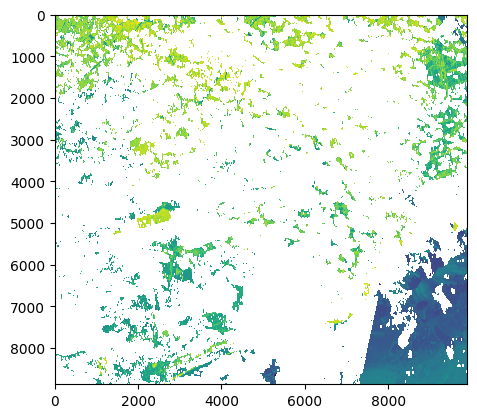

In [17]:
plt.imshow(average_ndvi.isel(time=0))

#####################################################################################

In [1]:
fill_nan_model = joblib.load('output/regressors/max/gb_cloud.pkl')

NameError: name 'joblib' is not defined

In [ ]:
mask = ~np.isnan(average_ndvi)
data = np.stack([average_vh.values[mask], average_vv.values[mask]], axis=1)
label = average_ndvi.values[mask]

In [ ]:
num_samples = 300

# Generate random indices
random_indices = np.random.choice(data.shape[0], size=num_samples, replace=False)

# Subset the data using the random indices
x = data[random_indices]
y = label[random_indices]

# Check the new shape
print(x.shape)
print(y.shape)

In [ ]:
np.savez("input/saved_datasets/test_aug.npz", data=x, label=y)

In [ ]:
preds = fill_nan_model.predict(x)
mse = mean_squared_error(y, preds)
mae = mean_absolute_error(y, preds)
r2 = r2_score(y, preds)
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")

#####################################################################################

In [18]:
train_path = "input/train_points/1130/ST_1130_points.shp"  
# train_path = "train/updated_data/ThuanHoa_DKS_Kappa.shp"
ground_points = load_data_geo(train_path)
ground_points.head()

,No,X,Y,LU2022,Hientrang,HT_code,geometry
0,1.0,603860.819,1081162.862,Pomelo,CLN,3,POINT (603860.819 1081162.862)
1,2.0,601306.410,1082782.940,Pomelo,CLN,3,POINT (601306.41 1082782.94)
2,3.0,601084.510,1081351.870,Pomelo,CLN,3,POINT (601084.51 1081351.87)
3,4.0,602193.760,1079205.220,Pomelo,CLN,3,POINT (602193.76 1079205.22)
4,5.0,602459.000,1080946.000,Pomelo,CLN,3,POINT (602459 1080946)


In [19]:
fill_nan_model = joblib.load('output/regressors/max/rf_cloud.pkl')

/env/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.3.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/env/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.3.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [20]:

def extract_data_with_HTcode(ground_points, average_ndvi, dsvh, dsvv):
    datasets = {}
    for idx, point in ground_points.iterrows():
        
        # Ensure each HT_code has its own dictionary
        if point.HT_code not in datasets:
            datasets[point.HT_code] = {'ndvi': [], 'vh': [], 'vv': []}
        # Get the data for this point
        ndvi_data = average_ndvi.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vh_data = dsvh.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vv_data = dsvv.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        
        # Append the data to the lists for this HT_code
        datasets[point.HT_code]['ndvi'].append(ndvi_data)
        datasets[point.HT_code]['vh'].append(vh_data)
        datasets[point.HT_code]['vv'].append(vv_data)
    
    return datasets

In [21]:
data = extract_data_with_HTcode(ground_points, average_ndvi, average_vh, average_vv)

*********************************************************************************************************

In [ ]:
index = 0

In [ ]:
ndvi = np.concatenate(data[index]['ndvi'])
vh = np.concatenate(data[index]['vh'])
vv = np.concatenate(data[index]['vv'])
X_pred = np.stack([vh, vv], axis=1)
print(ndvi.shape, X_pred.shape)

In [ ]:
mask = ~np.isnan(ndvi)
nonan_ndvi = ndvi[mask]
nonan_ndvi.shape

In [ ]:
pred_data = X_pred[mask]
pred_data.shape

In [ ]:
pred_data = pred_data[:75]
nonan_ndvi = nonan_ndvi[:75]
pred_data.shape

In [ ]:
preds = fill_nan_model.predict(pred_data)

In [ ]:
# print(nonan_ndvi)
# print(preds)

In [ ]:
mae = mean_squared_error(nonan_ndvi, preds)
r2 = r2_score(preds, nonan_ndvi)
print("MAE: ", mae)
print("R^2: ", r2)

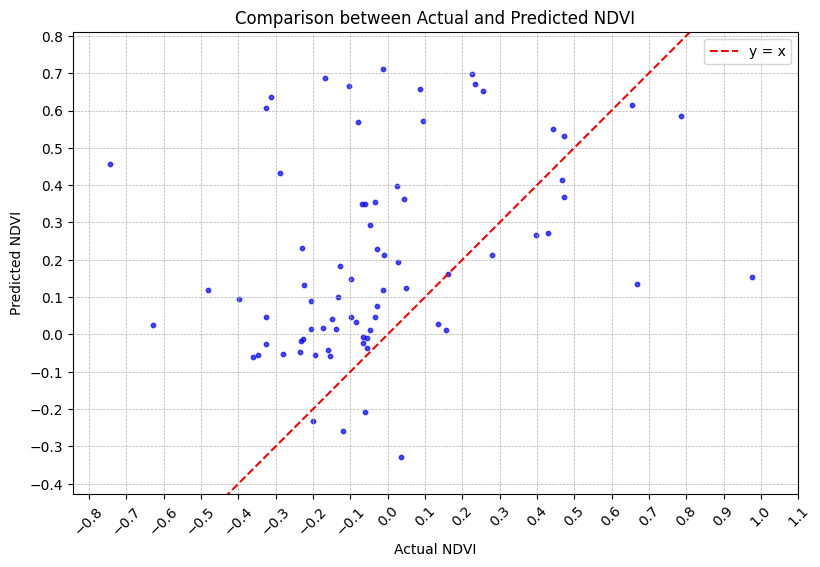

In [96]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(nonan_ndvi, preds, color='blue', alpha=0.7, s=10)
plt.plot([nonan_ndvi.min(), nonan_ndvi.max()], 
         [nonan_ndvi.min(), nonan_ndvi.max()], color='red', linestyle='--', label='y = x')

# Set equal scaling for the axes
plt.gca().set_aspect('equal', adjustable='box')

# Automatically adjust x and y axis limits based on data, with a margin of 0.1
x_min, x_max = nonan_ndvi.min() - 0.1, nonan_ndvi.max() + 0.1
y_min, y_max = preds.min() - 0.1, preds.max() + 0.1
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

# Set minor ticks for both axes at intervals of 0.1
plt.xticks([round(i, 1) for i in np.arange(x_min, x_max, 0.1)], rotation=45)
plt.yticks([round(i, 1) for i in np.arange(y_min, y_max, 0.1)])

plt.xlabel('Actual NDVI')
plt.ylabel('Predicted NDVI')
plt.title('Comparison between Actual and Predicted NDVI')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


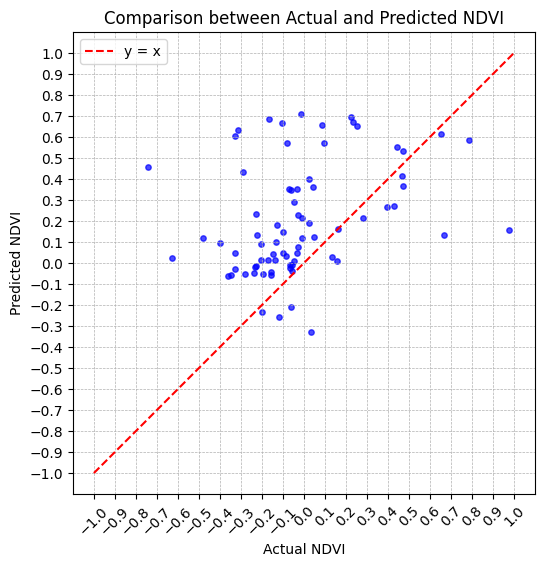

In [95]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(nonan_ndvi, preds, color='blue', alpha=0.7, s=15)
plt.plot([-1, 1], [-1, 1], color='red', linestyle='--', label='y = x')

# Set equal scaling and adjust x and y axis limits from -1 to 1
plt.gca().set_aspect('equal', adjustable='box')
# plt.xlim(-1, 1)  # Set x-axis limits from -1 to 1
# plt.ylim(-1, 1)  # Set y-axis limits from -1 to 1

# Add minor ticks at intervals of 0.1
plt.xticks([i * 0.1 for i in range(-10, 11)], rotation=45)
plt.yticks([i * 0.1 for i in range(-10, 11)])

plt.xlabel('Actual NDVI')
plt.ylabel('Predicted NDVI')
plt.title('Comparison between Actual and Predicted NDVI')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


In [ ]:
import numpy as np

# Function to filter out NaN values for each 'ndvi' array in each HT_code
def filter_non_nan_ndvi(data):
    filtered_data = {}
    
    for ht_code, attributes in data.items():
        # Initialize lists to store filtered arrays for 'ndvi', 'vh', and 'vv'
        filtered_ndvi = []
        filtered_vh = []
        filtered_vv = []
        
        # Iterate through each set of ndvi, vh, vv arrays
        for ndvi, vh, vv in zip(attributes['ndvi'], attributes['vh'], attributes['vv']):
            # Create masks to filter out NaN values based on 'ndvi' array
            non_nan_mask = ~np.isnan(ndvi)
            
            # Filter the arrays based on the mask
            filtered_ndvi.append(ndvi[non_nan_mask])
            filtered_vh.append(vh[non_nan_mask])
            filtered_vv.append(vv[non_nan_mask])
        
        # Only add if there are non-empty filtered values
        filtered_data[ht_code] = {
            'ndvi': filtered_ndvi,
            'vh': filtered_vh,
            'vv': filtered_vv
        }
    
    return filtered_data

# Example usage
filtered_datasets = filter_non_nan_ndvi(data)



In [ ]:
filtered_datasets

In [ ]:
import numpy as np

# Set the range of indices you want to include
indices = range(0, 11)  # Selects indices from 0 to 10
ht_code = 1
# Initialize empty lists to hold data for the selected range
X_list = []
y_list = []

# Loop over the indices and collect data
for index in indices:
    vh_data = filtered_datasets[ht_code]['vh'][index]
    vv_data = filtered_datasets[ht_code]['vv'][index]
    ndvi_data = filtered_datasets[ht_code]['ndvi'][index]
    
    # Stack VH and VV data for the current index
    X = np.column_stack((vh_data, vv_data))
    X_list.append(X)
    y_list.append(ndvi_data)

# Concatenate the lists to form the complete dataset
X_combined = np.concatenate(X_list, axis=0)
y_combined = np.concatenate(y_list, axis=0)
print("X shape:", X_combined.shape)
print("y shape:", y_combined.shape)


In [ ]:
preds = fill_nan_model.predict(X_combined)
mse = mean_squared_error(y_combined, preds)
mae = mean_absolute_error(y_combined, preds)
r2 = r2_score(preds, y_combined)
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")
# print(y)
# print(preds)

In [ ]:
import matplotlib.pyplot as plt
# Tạo biểu đồ với độ chia đồng nhất cho cả hai trục
# plt.figure(figsize=(10, 6))
plt.scatter(y_combined, preds, color='blue', alpha=0.7)
plt.plot([y_combined.min(), y_combined.max()],
         [y_combined.min(), y_combined.max()], color='red', linestyle='--', label='y = x')

# Thiết lập tỷ lệ các trục đồng nhất
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(y_combined.min() - 0.1, y_combined.max() + 0.1)  # Điều chỉnh giới hạn trục x
plt.ylim(y_combined.min() - 0.1, y_combined.max() + 0.1)  # Điều chỉnh giới hạn trục y

plt.xlabel('Actual NDVI')
plt.ylabel(' predicted NDVI')
plt.title('Comparing between actual and predict NDVI')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
########################################################################################################

In [36]:
# Assuming 'data' is the output of the function
ht_code = 0  # Replace with the specific HT code you want to extract
index = 5  # Replace with the index of the point you want to access (if multiple points are available)

# Extract the NDVI, VH, and VV values for that HT_code
ndvi_values = data[ht_code]['ndvi'][:index]
vh_values = data[ht_code]['vh'][:index]
vv_values = data[ht_code]['vv'][:index]

# print("NDVI Values:", ndvi_values)
# print("VH Values:", vh_values)
# print("VV Values:", vv_values)

In [37]:
ndvi_values

[array([        nan,         nan,         nan,  0.7838173 ,  0.2594822 ,
                nan,         nan, -0.01014197,         nan,         nan,
                nan,  0.04412892,         nan,  0.41975912], dtype=float32),
 array([        nan,  0.05541343,         nan,         nan,  0.04872111,
        -0.03975514, -0.02526664,  0.06633194, -0.03085015,         nan,
                nan,         nan,         nan,  0.304978  ], dtype=float32),
 array([        nan,  0.03639242,         nan, -0.02970295,         nan,
         0.21961932,  0.1123914 ,  0.00693567,  0.02815771,         nan,
                nan, -0.02027068,  0.07577639,  0.14754659], dtype=float32),
 array([       nan, 0.19116719,        nan, 0.63182616, 0.25624552,
        0.22557077, 0.21399492, 0.2436642 , 0.12472966,        nan,
               nan,        nan, 0.30766046, 0.17185405], dtype=float32),
 array([0.03151124,        nan,        nan,        nan,        nan,
               nan, 0.14684573, 0.1211228 ,        nan

In [ ]:
input_data = np.column_stack((vh_values, vv_values))

# Make predictions for each month
predicted_ndvi = fill_nan_model.predict(input_data)

# Print the predictions
print("Predicted NDVI for each month:", predicted_ndvi)

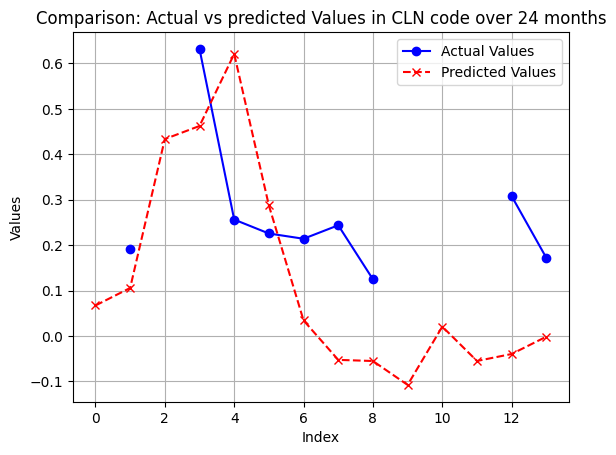

In [24]:
plt.plot(ndvi_values, marker='o', linestyle='-', color='b', label='Actual Values')

# Plotting the adjusted values
plt.plot(predicted_ndvi, marker='x', linestyle='--', color='r', label='Predicted Values')

# Adding labels and title
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison: Actual vs predicted Values in CLN code over 24 months')
# Adding grid
plt.grid(True)
# Adding legend to differentiate the lines
plt.legend()
# # # Adjusting the limits of the axes
# plt.xlim(0, 75)  # Example: Setting x-axis limits from 0 to 12
# plt.ylim(-1, 1)   # Example: Setting y-axis limits from 0 to 1
# Display the plot
plt.show()

In [25]:
# cấu hình nhãn dữ liệu
label_mapping = {
    "Lua tom": "0",
    "Lua": "1",
    "CHN": "2",
    "CLN": "3",
    "TS": "4",
    "Song": "5",
    "Dat xay dung": "6",
    "Rung": "7"
}

In [108]:
def draw(ndvi_values, predicted_ndvi, name):
    plt.plot(ndvi_values, marker='o', linestyle='-', color='b', label='Actual Values')
    plt.plot(predicted_ndvi, marker='x', linestyle='--', color='r', label='Predicted Values')
    # Adding labels and title
    plt.xlabel('Index')
    plt.ylabel('Values')
    plt.title(f'Comparison: Actual vs predicted Values in {name} code over 14 months')
    # Adding grid
    plt.grid(True)
    # Adding legend to differentiate the lines
    plt.legend()
    # # # Adjusting the limits of the axes
    plt.xlim(0, 25)  # Example: Setting x-axis limits from 0 to 12
    plt.ylim(-1, 1)   # Example: Setting y-axis limits from 0 to 1
    # Display the plot
    plt.show()

In [109]:
def show_images (ht_code, index, name):
    ndvi_values = data[ht_code]['ndvi'][index]
    vh_values = data[ht_code]['vh'][index]
    vv_values = data[ht_code]['vv'][index]
    input_data = np.column_stack((vh_values, vv_values))
    predicted_ndvi = fill_nan_model.predict(input_data)
    draw(ndvi_values, predicted_ndvi, name)
    

In [ ]:
for i in range(50):
    show_images(1, i, 'TS')

In [ ]:
^^^^^^^^^^^^^^^^^^^^^^^^^^^NEW VERSION OF GRPAH^^^^^^^^^^^^^^^^

In [114]:
import matplotlib.pyplot as plt



def draw(ndvi_values, predicted_values, name):
    for i, (ndvi, predicted) in enumerate(zip(ndvi_values, predicted_values)):
        # plt.plot(ndvi, marker='o', linestyle='-', label=f'Actual Values {i+1}')
        # plt.plot(predicted, marker='x', linestyle='--', label=f'Predicted Values {i+1}')
        plt.plot(ndvi, marker='o', linestyle='-', color='blue', markersize=4, linewidth=0.75)
        plt.plot(predicted, marker='x', linestyle='--', color='red', markersize=4, linewidth=0.75)
    
    # Adding labels and title
    plt.xlabel('Months')
    plt.ylabel('NDVI values')
    plt.title(f'Comparison: Actual vs Predicted Values in {name} code over 14 months')
    # Adding grid
    plt.grid(True)
    # Adding legend to differentiate the lines
    plt.legend()
    # Adjusting the limits of the axes
    plt.xlim(0, max(len(arr) for arr in ndvi_values))  # Adjust x-axis limits based on the longest array
    plt.ylim(-1, 1)  # Example: Setting y-axis limits
    # Display the plot
    plt.show()


In [115]:
def show_images(ht_code, indices, name):
    all_ndvi_values = []
    all_predicted_ndvi_values = []

    # Iterate over the list of vh_values and vv_values
    for index in range(indices):
        # Extract the values for the given index range
        ndvi_values = data[ht_code]['ndvi'][index]
        vh_values = data[ht_code]['vh'][index]
        vv_values = data[ht_code]['vv'][index]
        # Combine vh and vv into input data
        input_data = np.column_stack((vh_values, vv_values))
        # Predict NDVI values
        predicted_ndvi = fill_nan_model.predict(input_data)
        # Collect the values for plotting
        all_ndvi_values.append(ndvi_values)
        all_predicted_ndvi_values.append(predicted_ndvi)
    # Draw the plots for all the data
    draw(all_ndvi_values, all_predicted_ndvi_values, name)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


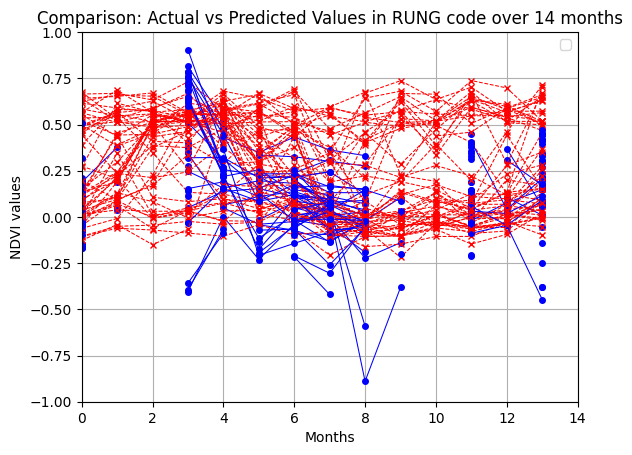

In [123]:
show_images(0, 50, 'RUNG')